In [184]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from shapely.geometry import box

In [185]:
import os
print(os.getcwd())

C:\Users\kalmanj\Documents\SCHOOL\Practicum\south-africa-healthcare


In [186]:
sal = gpd.read_file("../2011_census/2011_Census/ea_sal_kzn_gp.shp")

wards = gpd.read_file("../2023_Census/SA_Wards2020.shp")

wards_with_pop = gpd.read_file("../2023_Census/census_ward_2023_with_pop.csv")

In [187]:
import pandas as pd
pd.set_option('display.float_format', '{:,.0f}'.format)
import pandas as pd

pd.set_option('display.max_columns', 100)

In [188]:
wards = wards.merge(
    wards_with_pop[['WardID', 'Total',]],
    on='WardID',
    how='left'
)

In [189]:
wards = wards[wards['Province'].isin(['Gauteng', 'KwaZulu-Natal'])].copy()


In [190]:
sal['population'].isna().sum()

np.int64(2084)

In [191]:
sal_with_ward = gpd.read_file("../sal_w_ward_new.shp")

In [192]:

pd.set_option('display.float_format', '{:,.2f}'.format)

In [193]:
sal_with_ward=sal_with_ward.rename(columns={'census_war': 'WardID'})

In [194]:
sal_with_ward = sal_with_ward.merge(
    wards[['WardID', 'Total']],
    on='WardID',
    how='left'
)
    

In [195]:
sal_wards= sal_with_ward[['WardID', 'EA_CODE', 'sal2011_po', "Total", 'EA_GTYPE', 'EA_TYPE', 'F4_class', 'num_houses', 
                         'Black_Afri', 'White', 'Coloured', 'Indian_or', 'Other',    ]]
sal_wards = sal_wards.drop_duplicates(subset="EA_CODE")

In [196]:
sal_wards=sal_wards.rename(columns={'sal2011_po': 'sal2011_pop',
                            'Total':'ward2023_pop',
                                'F4_class': 'econ_status',
                                'num_houses': 'houses2011'})

In [197]:
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(r'_\*$', '', regex=True)
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(
    'Smallholdings', 'Small holdings'
)

In [198]:
sal_wards.loc[sal_wards['sal2011_pop'] == 0, 'sal2011_pop'] = sal_wards['houses2011']*3


sal_wards['area_km2'] = sal_with_ward.geometry.area / 1e6

sal_wards['sal_dense'] = (
    sal_wards['sal2011_pop'].astype(float) /
    sal_wards['area_km2'].astype(float)
)
sal_wards['log_density'] = np.log1p(sal_wards['sal_dense'])

In [199]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density
0,52103007,"50,310,272.00",559.00,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,131.00,558,0,0,1,0,6.07,92.05,4.53
1,52103007,"50,310,271.00",713.00,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,167.00,713,0,0,0,0,3.90,182.78,5.21
2,52103007,"50,310,262.00",443.00,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,135.00,443,0,0,0,0,1.93,229.94,5.44
3,52103007,"50,310,266.00",743.00,5886.912582199999633,Traditional,Traditional residential,Non_Wealthy,154.00,740,0,1,1,1,1.71,435.35,6.08
4,52103006,"50,310,265.00",339.00,7902.254373200000373,Traditional,Traditional residential,Non_Wealthy,92.00,339,0,0,0,0,4.05,83.61,4.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,59500015,"59,912,265.00",0.00,44864.912303999997675,Urban,Vacant,None,0.00,None,None,None,None,None,0.52,0.00,0.00
39173,59500103,"59,914,036.00",540.00,39704.126380000001518,Urban,Small holdings,Wealthy,180.00,None,None,None,None,None,4.06,133.14,4.90
39174,59500049,"59,915,062.00",0.00,52055.310791000003519,Urban,Formal residential,None,0.00,None,None,None,None,None,0.02,0.00,0.00
39175,59500063,"59,911,731.00",78.00,41787.592755999998190,Urban,Informal residential,Non_Wealthy,26.00,None,None,None,None,None,0.54,144.44,4.98


In [200]:
sal_wards['log_density'].describe()

count   38,380.00
mean         7.41
std          2.48
min          0.00
25%          6.31
50%          8.11
75%          9.14
max         13.40
Name: log_density, dtype: float64

In [201]:
sal_wards['ward2023_pop'] = pd.to_numeric(sal_wards['ward2023_pop'], errors='coerce')
sal_wards['sal2011_pop']= pd.to_numeric(sal_wards['sal2011_pop'], errors='coerce')

In [202]:
sal_wards[sal_wards.duplicated(subset='EA_CODE', keep=False)]
sal_wards = sal_wards.drop_duplicates(subset='EA_CODE', keep='first')

In [203]:
#Calculating proportion of SAL pop within Ward pop

ward2011_sum = sal_wards.groupby('WardID', as_index=False)['sal2011_pop'].sum()
ward2011_sum = ward2011_sum.rename(columns={'sal2011_pop': 'ward2011_sum'})
sal_wards = sal_wards.merge(
    ward2011_sum,
    on='WardID',
    how='left'
)


sal_wards['share2011']=sal_wards['sal2011_pop']/sal_wards['ward2011_sum']

In [204]:
sal_wards['share2011'].describe()

count   38,380.00
mean         0.04
std          0.04
min          0.00
25%          0.02
50%          0.02
75%          0.05
max          0.60
Name: share2011, dtype: float64

In [205]:
#SAL weights based on density and area

In [206]:

# gtype_growth = sal_wards.groupby('EA_TYPE').agg(
#     pop2011=('ward2011_sum','sum'),
#     pop2023=('ward2023_pop','sum')
# ).reset_index()


# gtype_growth['growth_ratio'] = gtype_growth['pop2023'] / gtype_growth['pop2011']

# weights_dict = dict(zip(gtype_growth['EA_TYPE'], gtype_growth['growth_ratio']))
# sal_wards['gweight'] = sal_wards['EA_TYPE'].map(weights_dict)

In [207]:
# sal_wards['gweight'].describe()

In [208]:
sal_wards['dasym_weight']= sal_wards['share2011']*sal_wards['log_density']
sal_wards['dasym_weight'] = sal_wards['dasym_weight']/sal_wards.groupby('WardID')['dasym_weight'].transform('sum')

In [209]:
sal_wards['dasym_weight'].describe()

count   38,380.00
mean         0.04
std          0.04
min          0.00
25%          0.01
50%          0.02
75%          0.05
max          0.59
Name: dasym_weight, dtype: float64

In [210]:
#Estimating 2023 SAL population based on weights and 2023 ward level counts
sal_wards['sal2023_est'] = sal_wards['dasym_weight']* sal_wards['ward2023_pop']



In [211]:
#calculating growth rate using 2011 counts and 2023 estimate

sal_wards['growth_rate'] = ((sal_wards['sal2023_est'] / sal_wards['sal2011_pop'])**(1/12)) - 1

In [212]:
#Readjusting 2026 predictions to stay within total population margins and account for sprawl from one SAL into another
#wards['Total'] = pd.to_numeric(wards['Total'], errors='coerce')
#totals2011 = sal_wards['sal2011_pop'].sum()
#totals2023 = wards['Total'].sum()

#annual_growth = ((totals2023 / totals2011)**(1/12)) 

#target_2026 = totals2023 * (( annual_growth)**3)

#sal_wards['share2023'] = sal_wards['sal2023_est'] / totals2023

#sal_wards['sal2026_pred'] = sal_wards['share2023'] * target_2026

In [213]:
######

In [214]:
sal_wards['ward2023_pop'].describe()

count    38,380.00
mean     27,492.24
std      19,153.56
min       1,443.66
25%      11,208.62
50%      23,592.52
75%      37,830.58
max     126,727.52
Name: ward2023_pop, dtype: float64

In [215]:
sal_wards['sal2023_est'].describe()

count   38,380.00
mean       717.13
std        513.69
min          0.00
25%        351.65
50%        664.61
75%        992.97
max     14,387.06
Name: sal2023_est, dtype: float64

In [216]:
#sal_wards['sal2026_pred'].describe()

In [217]:
#sal_wards['sal2026_pred'].sum()

In [218]:
sal_wards['sal2023_est'].sum()

np.float64(27523329.36133701)

In [219]:
wards['ward2023_pop'] = pd.to_numeric(wards['Total'], errors='coerce')

In [220]:
wards['ward2023_pop'].sum()

np.float64(27523329.36133701)

In [221]:
sal_wards['sal2023_est'].sum()-wards['ward2023_pop'].sum() 

np.float64(0.0)

In [222]:
sal_wards[['sal2011_pop','sal2023_est', ]].sum()

sal2011_pop   24,694,905.00
sal2023_est   27,523,329.36
dtype: float64

In [223]:
sal_wards['EA_CODE'] = sal_wards['EA_CODE'].astype('Int64')   # or str if needed

In [224]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density,ward2011_sum,share2011,dasym_weight,sal2023_est,growth_rate
0,52103007,50310272,559.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,131.00,558,0,0,1,0,6.07,92.05,4.53,"7,387.00",0.08,0.07,391.86,-0.03
1,52103007,50310271,713.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,167.00,713,0,0,0,0,3.90,182.78,5.21,"7,387.00",0.10,0.10,574.86,-0.02
2,52103007,50310262,443.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,135.00,443,0,0,0,0,1.93,229.94,5.44,"7,387.00",0.06,0.06,372.81,-0.01
3,52103007,50310266,743.00,"5,886.91",Traditional,Traditional residential,Non_Wealthy,154.00,740,0,1,1,1,1.71,435.35,6.08,"7,387.00",0.10,0.12,698.39,-0.01
4,52103006,50310265,339.00,"7,902.25",Traditional,Traditional residential,Non_Wealthy,92.00,339,0,0,0,0,4.05,83.61,4.44,"8,923.00",0.04,0.03,272.54,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38375,59500015,59912265,0.00,"44,864.91",Urban,Vacant,None,0.00,None,None,None,None,None,0.52,0.00,0.00,"33,583.00",0.00,0.00,0.00,NaN
38376,59500103,59914036,540.00,"39,704.13",Urban,Small holdings,Wealthy,180.00,None,None,None,None,None,4.06,133.14,4.90,"33,248.00",0.02,0.01,474.30,-0.01
38377,59500049,59915062,0.00,"52,055.31",Urban,Formal residential,None,0.00,None,None,None,None,None,0.02,0.00,0.00,"41,652.00",0.00,0.00,0.00,NaN
38378,59500063,59911731,78.00,"41,787.59",Urban,Informal residential,Non_Wealthy,26.00,None,None,None,None,None,0.54,144.44,4.98,"36,133.00",0.00,0.00,58.28,-0.02


In [225]:
print(sal_wards.head().to_markdown(index=False, floatfmt=",.2f"))

|   WardID |   EA_CODE |   sal2011_pop |   ward2023_pop | EA_GTYPE    | EA_TYPE                 | econ_status   |   houses2011 |   Black_Afri |   White |   Coloured |   Indian_or |   Other |   area_km2 |   sal_dense |   log_density |   ward2011_sum |   share2011 |   dasym_weight |   sal2023_est |   growth_rate |
|---------:|----------:|--------------:|---------------:|:------------|:------------------------|:--------------|-------------:|-------------:|--------:|-----------:|------------:|--------:|-----------:|------------:|--------------:|---------------:|------------:|---------------:|--------------:|--------------:|
| 52103007 |  50310272 |        559.00 |       5,886.91 | Traditional | Traditional residential | Non_Wealthy   |       131.00 |          558 |       0 |          0 |           1 |       0 |       6.07 |       92.05 |          4.53 |       7,387.00 |        0.08 |           0.07 |        391.86 |         -0.03 |
| 52103007 |  50310271 |        713.00 |       5,886.91 | 

In [226]:
gtype_summary = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('sal2011_pop','sum'),
    pop2023=('sal2023_est','sum'),
).reset_index()

gtype_summary['growth_rate_2011_2023'] = (
    ((gtype_summary['pop2023'] / gtype_summary['pop2011']) ** (1/12) - 1)*100
)



In [227]:
sal_wards['sal_dense'].describe()

count    38,380.00
mean      7,094.11
std      12,762.57
min           0.00
25%         547.08
50%       3,315.59
75%       9,331.02
max     662,594.71
Name: sal_dense, dtype: float64

In [228]:
gtype_summary

,EA_TYPE,pop2011,pop2023,growth_rate_2011_2023
0,Collective living quarters,"341,825.00","286,717.06",-1.45
1,Commercial,"354,128.00","251,390.43",-2.82
2,Farms,"464,324.00","239,162.75",-5.38
3,Formal residential,"8,060,534.00","7,759,042.31",-0.32
4,Industrial,"206,049.00","142,473.03",-3.03
5,Informal residential,"1,849,126.00","2,486,815.69",2.50
6,Parks and recreation,"21,996.00","11,008.93",-5.60
7,Small holdings,"281,723.00","221,943.54",-1.97
8,Township,"7,677,887.00","9,898,540.06",2.14
9,Traditional residential,"5,162,867.00","5,965,887.07",1.21


In [229]:
#print(gtype_summary.to_markdown(index=False, floatfmt=",.2f"))

In [230]:
sal_map = sal.merge(
    sal_wards,
    on='EA_CODE',
    how='left'
)


C:\Users\kalmanj\AppData\Local\Temp\ipykernel_28812\247600462.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  sal_map = sal.merge(


In [231]:
sal_wards['sal2023_est'].describe()


count   38,380.00
mean       717.13
std        513.69
min          0.00
25%        351.65
50%        664.61
75%        992.97
max     14,387.06
Name: sal2023_est, dtype: float64

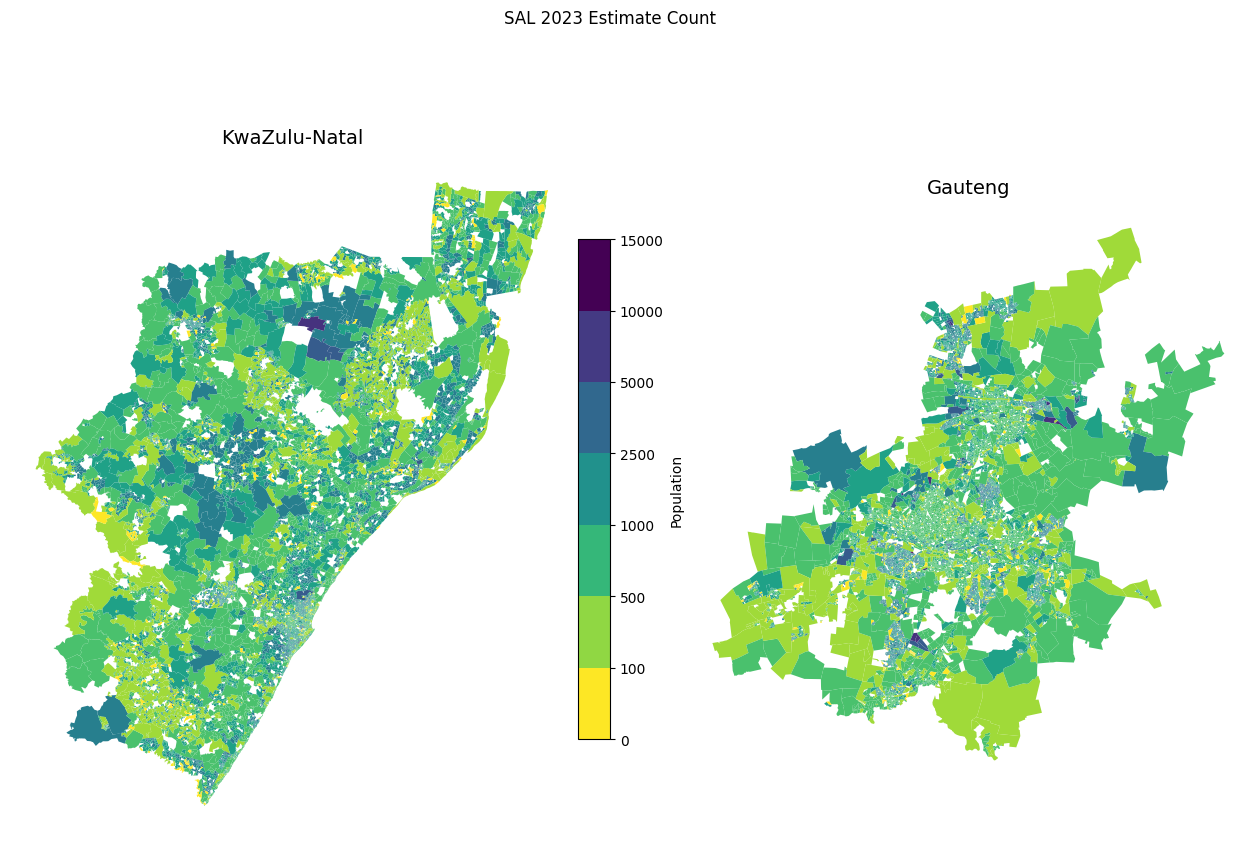

Map saved to pop2023estimate.png


In [232]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

# consistent bins
bin_edges = [0,100, 500,1000, 2500, 5000, 10000, 15000]

cmap = mpl.cm.viridis_r

for i, prov in enumerate(provinces):

    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    subset = subset[subset['sal2023_est'].notna()]  # drop missing

    subset.plot(
        column='sal2023_est',
        cmap=cmap,
        scheme='UserDefined',
        classification_kwds={'bins': bin_edges},
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# ---- shared colorbar (fixed mapping) ----
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population")

plt.suptitle("SAL 2023 Estimate Count")

output_file = "pop2023estimate.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [233]:
sal_map['dense_2023']= sal_map['sal2023_est']/sal_map['area_km2']

In [234]:
sal_map['dense_2023'].describe()

count    34,067.00
mean      8,098.70
std      14,205.95
min           0.00
25%         512.54
50%       3,206.33
75%      11,208.58
max     621,630.22
Name: dense_2023, dtype: float64

In [235]:
sal_map['log_density'] = np.log1p(sal_map['dense_2023'])

In [236]:
sal_map['log_density'].describe()

count   34,067.00
mean         7.39
std          2.64
min          0.00
25%          6.24
50%          8.07
75%          9.32
max         13.34
Name: log_density, dtype: float64

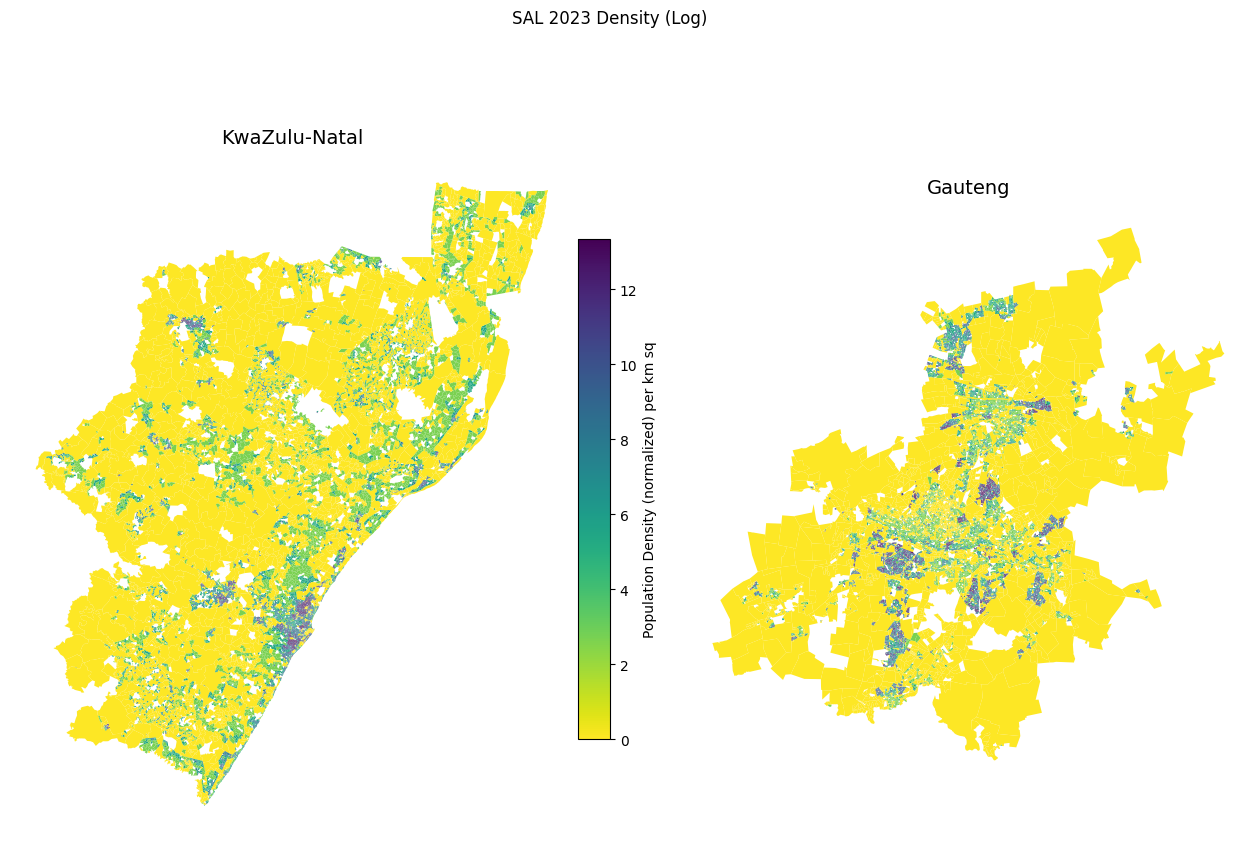

Map saved to popdensity.png


In [237]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    
    # compute quintile breaks
    subset.plot(
        column='log_density',
        cmap='viridis_r',
        legend=False,
        scheme='Quantiles',
        k=6,
        ax=axes[i]
    )
        
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.Normalize(
    vmin=sal_map['log_density'].min(),
    vmax=sal_map['log_density'].max()
)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population Density (normalized) per km sq")
plt.suptitle("SAL 2023 Density (Log)")
output_file = "popdensity.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [238]:
sal_wards.to_csv('pop_pred_final.csv', index=False)

In [239]:
sal_map = sal_map.to_crs(sal_with_ward.crs)

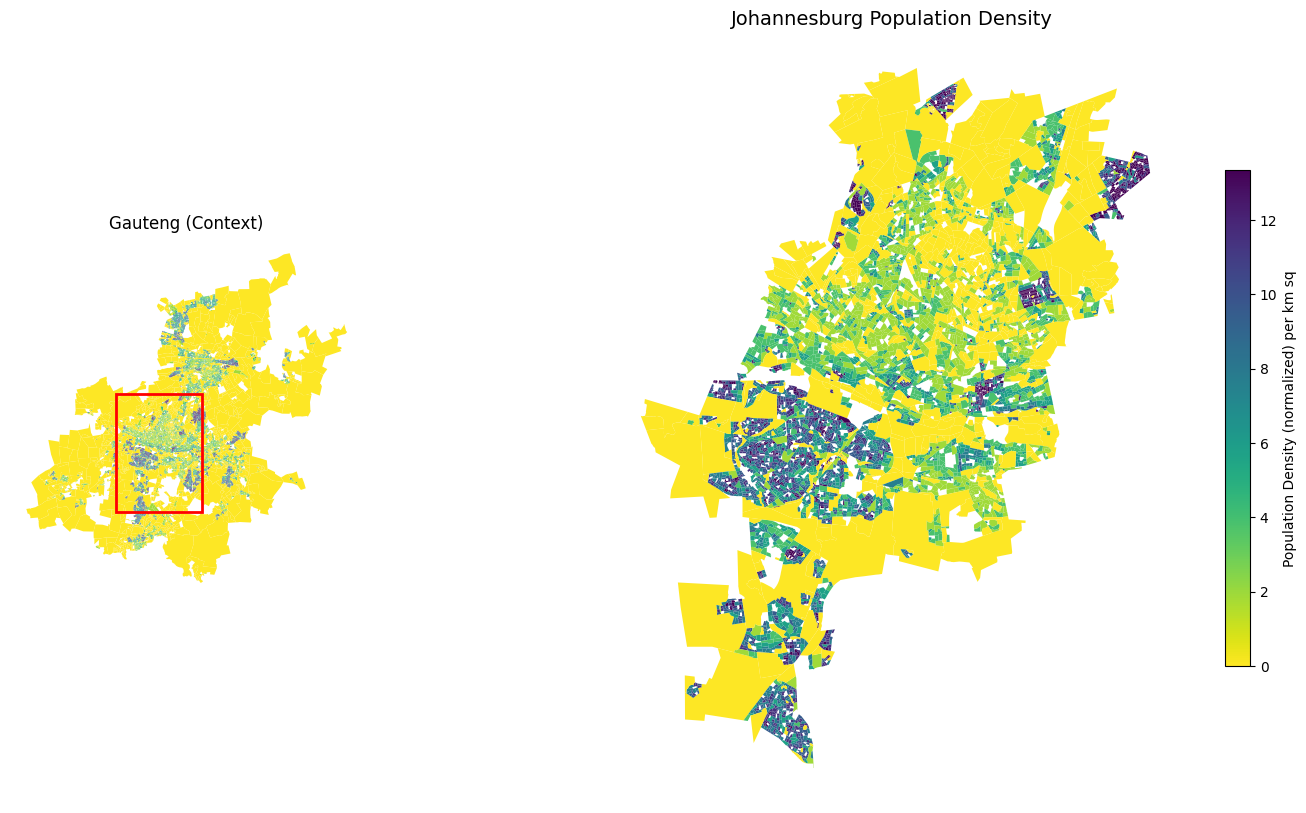

Map saved to gauteng_joburg_sidebyside_rect.png


In [240]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# -------------------------
# FILTER DATA
# -------------------------
gauteng = sal_map[sal_map['PR_NAME'].str.contains("Gauteng", case=False, na=False)].copy()

jhb = gauteng[gauteng['MN_NAME'].str.contains("Johannesburg", case=False, na=False)]

# -------------------------
# FIGURE (Joburg bigger)
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,10),
    gridspec_kw={'width_ratios': [1, 2]}  # Joburg panel bigger
)

# -------------------------
# LEFT: GAUTENG (context)
# -------------------------
gauteng.plot(
    column='log_density',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[0]
)

# Add rectangular outline for Johannesburg
xmin, ymin, xmax, ymax = jhb.total_bounds
pad_x = (xmax - xmin) * 0.02  # slight padding
pad_y = (ymax - ymin) * 0.02

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2*pad_x,
    (ymax - ymin) + 2*pad_y,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
axes[0].add_patch(rect)

axes[0].set_title("Gauteng (Context)", fontsize=12)
axes[0].axis('off')

# -------------------------
# RIGHT: JOHANNESBURG (zoom)
# -------------------------
jhb.plot(
    column='log_density',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[1]
)

axes[1].set_title("Johannesburg Population Density ", fontsize=14)
axes[1].axis('off')

# -------------------------
# SHARED COLORBAR
# -------------------------
norm = mpl.colors.Normalize(
    vmin=sal_map['log_density'].min(),
    vmax=sal_map['log_density'].max()
)

sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    pad=0.04
)
cbar.set_label("Population Density (normalized) per km sq")

# -------------------------
# SAVE
# -------------------------
output_file = "gauteng_joburg_sidebyside_rect.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()
print(f"Map saved to {output_file}")

In [241]:
sal_wards['sal_dense'].describe()

count    38,380.00
mean      7,094.11
std      12,762.57
min           0.00
25%         547.08
50%       3,315.59
75%       9,331.02
max     662,594.71
Name: sal_dense, dtype: float64

In [242]:
print(sal_with_ward.crs)

EPSG:32735


In [243]:
print(sal_wards['share2011'].describe().to_markdown(index=False, floatfmt=",.2f"))

|   share2011 |
|------------:|
|   38,380.00 |
|        0.04 |
|        0.04 |
|        0.00 |
|        0.02 |
|        0.02 |
|        0.05 |
|        0.60 |


In [244]:
sal_wards[sal_wards['sal_dense'] >100000].sort_values('area_km2')

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density,ward2011_sum,share2011,dasym_weight,sal2023_est,growth_rate
32761,79900092,79912522,445.00,"18,864.60",Urban,Collective living quarters,Non_Wealthy,4.00,416,20,9,0,0,0.00,"287,063.27",12.57,"45,971.00",0.01,0.01,232.52,-0.05
14059,59500022,59913668,"1,306.00","21,793.91",Urban,Township,Non_Wealthy,10.00,1304,0,2,0,0,0.00,"662,594.71",13.40,"32,132.00",0.04,0.06,"1,225.26",-0.01
12534,59500032,59912963,462.00,"14,370.55",Urban,Formal residential,Wealthy,10.00,434,1,17,0,10,0.00,"193,206.77",12.17,"30,563.00",0.02,0.02,270.91,-0.04
12590,59500026,59912424,636.00,"26,827.00",Urban,Formal residential,Wealthy,4.00,603,5,8,20,0,0.00,"241,602.60",12.40,"48,180.00",0.01,0.02,420.84,-0.03
26006,79800123,79813410,502.00,"24,539.00",Urban,Formal residential,Wealthy,3.00,502,0,0,0,0,0.00,"189,608.54",12.15,"35,377.00",0.01,0.02,398.63,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12607,59500026,59912414,"1,723.00","26,827.00",Urban,Formal residential,Wealthy,23.00,1407,194,58,60,4,0.02,"101,856.19",11.53,"48,180.00",0.04,0.04,"1,060.65",-0.04
26061,79800062,79812267,"3,095.00","14,993.25",Urban,Formal residential,Wealthy,20.00,3068,6,15,6,0,0.02,"151,038.37",11.93,"31,813.00",0.10,0.10,"1,520.16",-0.06
26057,79800062,79812266,"2,206.00","14,993.25",Urban,Formal residential,Wealthy,23.00,2188,2,7,1,8,0.02,"100,505.80",11.52,"31,813.00",0.07,0.07,"1,046.50",-0.06
26379,79800061,79813441,"2,967.00","13,977.14",Urban,Collective living quarters,Non_Wealthy,11.00,2957,6,2,1,1,0.02,"124,315.56",11.73,"13,612.00",0.22,0.27,"3,726.74",0.02


In [245]:
cols = ['sal2023_est', 'sal2011_pop', 'growth_rate', 
        'dasym_weight', 'share2011', 'log_density']

summary = sal_wards[cols].describe()

print(gtype_summary.to_markdown(floatfmt=",.3f"))

|    | EA_TYPE                    |       pop2011 |       pop2023 |   growth_rate_2011_2023 |
|---:|:---------------------------|--------------:|--------------:|------------------------:|
|  0 | Collective living quarters |   341,825.000 |   286,717.062 |                  -1.454 |
|  1 | Commercial                 |   354,128.000 |   251,390.430 |                  -2.815 |
|  2 | Farms                      |   464,324.000 |   239,162.748 |                  -5.379 |
|  3 | Formal residential         | 8,060,534.000 | 7,759,042.311 |                  -0.317 |
|  4 | Industrial                 |   206,049.000 |   142,473.030 |                  -3.028 |
|  5 | Informal residential       | 1,849,126.000 | 2,486,815.695 |                   2.500 |
|  6 | Parks and recreation       |    21,996.000 |    11,008.926 |                  -5.605 |
|  7 | Small holdings             |   281,723.000 |   221,943.536 |                  -1.968 |
|  8 | Township                   | 7,677,887.000 | 9,898,54

In [246]:
print(sal_wards.loc[sal_wards['growth_rate'].idxmin()].to_markdown(index=True, floatfmt=",.2f"))

|              | 36132                  |
|:-------------|:-----------------------|
| WardID       | 52805012               |
| EA_CODE      | 58810097               |
| sal2011_pop  | 1.0                    |
| ward2023_pop | 10169.616012           |
| EA_GTYPE     | Traditional            |
| EA_TYPE      | Vacant                 |
| econ_status  | Non_Residential        |
| houses2011   | 15.0                   |
| Black_Afri   | 0                      |
| White        | 0                      |
| Coloured     | 0                      |
| Indian_or    | 0                      |
| Other        | 0                      |
| area_km2     | 77.77991507307826      |
| sal_dense    | 0.012856789558852671   |
| log_density  | 0.012774842675117377   |
| ward2011_sum | 9292.0                 |
| share2011    | 0.00010761945759793371 |
| dasym_weight | 3.2707980640609965e-07 |
| sal2023_est  | 0.0033262760364293313  |
| growth_rate  | -0.37842072737241883   |


In [247]:
sal_wards.loc[sal_wards['sal2023_est'].idxmax()]

WardID             79800040
EA_CODE            79812990
sal2011_pop       11,717.00
ward2023_pop      32,678.23
EA_GTYPE              Urban
EA_TYPE            Township
econ_status     Non_Wealthy
houses2011            26.00
Black_Afri            11662
White                     3
Coloured                 16
Indian_or                 7
Other                    29
area_km2               0.47
sal_dense         24,754.07
log_density           10.12
ward2011_sum      27,641.00
share2011              0.42
dasym_weight           0.44
sal2023_est       14,387.06
growth_rate            0.02
Name: 28532, dtype: object

In [248]:
print(sal.crs)

EPSG:4326


C:\Users\kalmanj\AppData\Local\Temp\ipykernel_28812\2445794048.py:8: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  pop = sal.merge(sal_wards, on="EA_CODE", how="left")


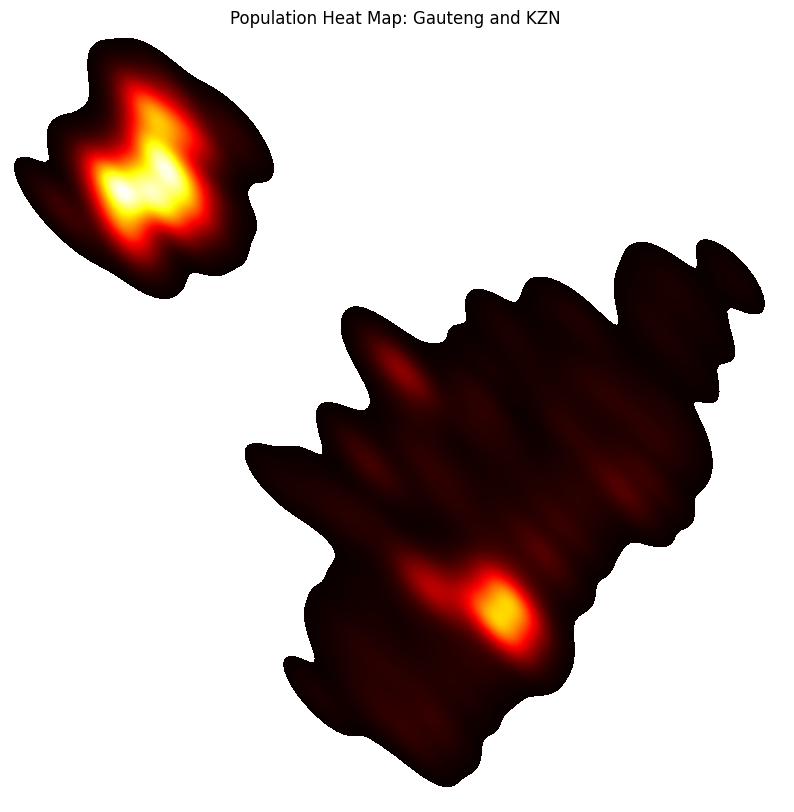

In [249]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. MERGE
# ----------------------------
pop = sal.merge(sal_wards, on="EA_CODE", how="left")

pop = gpd.GeoDataFrame(pop, geometry="geometry", crs=sal.crs)

# ----------------------------
# 2. PROJECT (important for KDE)
# ----------------------------
pop = pop.to_crs(epsg=3857)

# ----------------------------
# 3. CENTROIDS
# ----------------------------
pop["geometry"] = pop.geometry.centroid

# ----------------------------
# 4. CLEAN WEIGHTS (NO duplication)
# ----------------------------
pop["weight"] = pop["sal2023_est"].fillna(0)

# ----------------------------
# 5. EXTRACT COORDINATES
# ----------------------------
x = pop.geometry.x
y = pop.geometry.y

# ----------------------------
# 6. KDE WITH WEIGHTS (THIS IS THE KEY FIX)
# ----------------------------
plt.figure(figsize=(10, 10))

sns.kdeplot(
    x=x,
    y=y,
    weights=pop["weight"],   # 🔥 correct method
    fill=True,
    cmap="hot",
    levels=200,
    bw_adjust=0.6,        # 🔥 LOWER = more detail (try 0.3–0.7)
    thresh=0.01,          # keeps faint structure visible
    cut=2     
)

plt.title("Population Heat Map: Gauteng and KZN ")
plt.axis("off")

output_file = "heatmap.png"
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()